In [1]:
# Project 3 - shipwrecks. (Testing datasets)
# Testing Admiralty dataset: Wrecks and Obstructions Shapefiles
#An extensive data set containing over 94,000 charted, uncharted, live and dead wrecks and obstructions from around the world. Updated on a quarterly basis
#Updated Jan 2025
#(https://datahub.admiralty.co.uk/portal/home/item.html?id=4dbf2ace22bf4f9785fb445d0593bc2c)

# %%
import numpy as np
import pandas as pd

import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from dateutil import parser
from sklearn.cluster import DBSCAN
from shapely.geometry import Point, Polygon



points_dates = gpd.read_file("same_date_cleaned_points.csv")
points_iso = gpd.read_file("admiralty_iso_dates.csv")
points = gpd.read_file("Points.shp")
areas = gpd.read_file("Areas.shp")
noaa_points = gpd.read_file("Noaagovwrecks/General_Wreck_point.shp")
noaa_areas = gpd.read_file("Noaagovwrecks/General_Wreck_area.shp")


In [3]:
# Find the percentage of rows with data about the circumstance of sinking vs the empty rows in the data set
# first step, filter out the NaN
points_iso['circumstan_cleaned'] = points_iso['circumstan'].astype(str).str.strip().str.lower().replace('nan', np.nan)

# Step 2: add all the possible variations of no value by guessing the other option
missing_values = ["", "unknown", "not recorded", "?", "n/a", "none", np.nan]

# Total rows
total_rows = len(points_iso)

# Count rows with missing or unclear data
missing_count = points_iso['circumstan_cleaned'].isin(missing_values).sum()

# Count rows with valid/known data
known_count = total_rows - missing_count

# Calculate percentages
missing_pct = (missing_count / total_rows) * 100
known_pct = (known_count / total_rows) * 100
print(f"✅ Known circumstance: {known_pct:.2f}%")
print(f"❌ Missing/unknown circumstance: {missing_pct:.2f}%")

✅ Known circumstance: 21.09%
❌ Missing/unknown circumstance: 78.91%


In [4]:
# use this code to filter by specific column and show all wreck info
# for example: deepest recorded wreck, biggest recorded wreck, etc etc
# In this case: What is the date of the first recorded wreck that included information on the circumstance of sinking
# Step 1: Filter only known circumstances

valid_data = points_iso[~points_iso['circumstan_cleaned'].isin(missing_values)].copy()

# Step 2: Convert date_sunk to datetime (coerce errors into NaT)
valid_data['date_sunk'] = pd.to_datetime(valid_data['date_sunk'], errors='coerce')

# Step 3: Drop rows with invalid/missing dates
valid_data = valid_data.dropna(subset=['date_sunk'])

# Step 4: Find the earliest date
earliest_date = valid_data['date_sunk'].min()

print(f"🕰️ Earliest shipwreck with known circumstance: {earliest_date.date()}")


🕰️ Earliest shipwreck with known circumstance: 1684-04-04


In [5]:
# show relevant columns for graphs and plots on this wreck
row = valid_data[valid_data['date_sunk'] == earliest_date][[
    'wreck_id', 'flag', 'circumstan', 'cargo', 'position', 'depth',
    'type', 'length', 'height', 'width', 'tonnage', 'last_detec', 'date_sunk'
]].iloc[0]

# Reorder: date_sunk first
ordered_row = {'date_sunk': row['date_sunk']}
ordered_row.update({k: v for k, v in row.items() if k != 'date_sunk'})

# Print cleaned output, using "Unknown" for empty values
for k, v in ordered_row.items():
    if k == 'date_sunk' and pd.notna(v):
        v = pd.to_datetime(v).date()
    val_str = str(v).strip() if pd.notna(v) and str(v).strip() else "unknown"
    print(f"{k}:{val_str}")
    
    # if you want to print and leave out all the "Unknown" columns (for example to show tooltip information)
row = valid_data[valid_data['date_sunk'] == earliest_date][[
    'date_sunk', 'position', 'flag', 'circumstan', 'cargo', 'wreck_id'
]].iloc[0]

for k, v in row.items():
    if pd.notna(v) and str(v).strip():
        if k == 'date_sunk':
            v = pd.to_datetime(v).date()
        print(f"{k}:{str(v).strip()}")



date_sunk:1684-04-04
wreck_id:17300
flag:GB
circumstan:CAPTURED DUTCH FLY-BOAT USED IN EVACUATION OF TANGIERS. WAS ON PASSAGE TO ENGLAND WHEN SHE RAN ON TO THE ROCKS AT GUNWALLOE DURING A STORM.
cargo:general and mixed goods
position:50 2.369 N,5 16.461 W
depth:unknown
type:unknown
length:unknown
height:unknown
width:unknown
tonnage:unknown
last_detec:2009
date_sunk:1684-04-04
position:50 2.369 N,5 16.461 W
flag:GB
circumstan:CAPTURED DUTCH FLY-BOAT USED IN EVACUATION OF TANGIERS. WAS ON PASSAGE TO ENGLAND WHEN SHE RAN ON TO THE ROCKS AT GUNWALLOE DURING A STORM.
cargo:general and mixed goods
wreck_id:17300


In [6]:
# if you want to print and leave out all the "Unknown" columns (for example to show tooltip information)
row = valid_data[valid_data['date_sunk'] == earliest_date][[
    'date_sunk', 'position', 'flag', 'circumstan', 'cargo', 'wreck_id'
]].iloc[0]

for k, v in row.items():
    if pd.notna(v) and str(v).strip():
        if k == 'date_sunk':
            v = pd.to_datetime(v).date()
        print(f"{k}:{str(v).strip()}")

date_sunk:1684-04-04
position:50 2.369 N,5 16.461 W
flag:GB
circumstan:CAPTURED DUTCH FLY-BOAT USED IN EVACUATION OF TANGIERS. WAS ON PASSAGE TO ENGLAND WHEN SHE RAN ON TO THE ROCKS AT GUNWALLOE DURING A STORM.
cargo:general and mixed goods
wreck_id:17300


In [9]:
#Cluster coordinates of shipwrecks into top 5 areas with most shipwrecks in the world

# Make sure lat and lon are numeric, and drop any rows with missing values
points_dates['lat'] = pd.to_numeric(points_dates['lat'], errors='coerce')
points_dates['lon'] = pd.to_numeric(points_dates['lon'], errors='coerce')
points_dates = points_dates.dropna(subset=['lat', 'lon'])

# Convert lat/lon values to radians
coords = np.radians(points_dates[['lat', 'lon']].values.astype(float))

# Use DBSCAN clustering with a ~10 km radius (epsilon in radians)
kms_per_radian = 6371.0088
epsilon = 10 / kms_per_radian
db = DBSCAN(eps=epsilon, min_samples=5, algorithm='ball_tree', metric='haversine').fit(coords)


# Assign the cluster labels
points_dates['cluster'] = db.labels_

# Exclude noise (-1) and find top 5 densest clusters
top_clusters = points_dates[points_dates['cluster'] != -1]['cluster'].value_counts().head(5).index

# Map clusters to Area labels, in order so that Area 1 has the most wrecks.
area_map = {cluster: f"Area {i+1}" for i, cluster in enumerate(top_clusters)}
points_dates['area'] = points_dates['cluster'].map(area_map)

# Calculate the wreck count for each area (clusters excluded if area is NaN)
wreck_counts = points_dates.groupby('area').size().to_dict()
points_dates['wreck_count'] = points_dates['area'].map(wreck_counts)

# Optional: filter to show only the top 5 areas, and then sort by area label (Area 1,2,...)
area_order = [f"Area {i+1}" for i in range(5)]
filtered_sorted = points_dates[points_dates['area'].isin(area_order)] \
                    .sort_values(by='area', key=lambda x: x.map({area: i for i, area in enumerate(area_order)})) \
                    .reset_index(drop=True)

# # Display the results (showing lat, lon, area, and wreck_count)
# print(filtered_sorted[['lat', 'lon', 'area', 'wreck_count']].head(20))

summary = filtered_sorted.groupby('area')['wreck_count'].first().reset_index()
print(summary.sort_values(by='wreck_count', ascending=False))



     area  wreck_count
0  Area 1      39097.0
1  Area 2       3014.0
2  Area 3       1553.0
3  Area 4        996.0
4  Area 5        758.0


In [10]:
# Build a summary table with wreck count, bounding box, and center point
top5_wrecks = []

for area, group in filtered_sorted.groupby('area'):
    wreck_count = group.shape[0]
    
    # Bounding box
    min_lat, max_lat = group['lat'].min(), group['lat'].max()
    min_lon, max_lon = group['lon'].min(), group['lon'].max()
    
    # Center point (mean)
    center_lat = group['lat'].mean()
    center_lon = group['lon'].mean()
    
    top5_wrecks.append({
        'area': area,
        'wreck_count': wreck_count,
        'center_lat': round(center_lat, 6),
        'center_lon': round(center_lon, 6),
        'min_lat': round(min_lat, 6),
        'max_lat': round(max_lat, 6),
        'min_lon': round(min_lon, 6),
        'max_lon': round(max_lon, 6)
    })

# Convert to DataFrame for easy export or viewing
top5_wreck_10 = pd.DataFrame(top5_wrecks).sort_values(by='area')

# Display the table
print(top5_wreck_10.to_string(index=False))

# Optional: save to CSV if needed
top5_wreck_10.to_csv("top5_wreck_10.csv", index=False)


  area  wreck_count  center_lat  center_lon  min_lat  max_lat   min_lon   max_lon
Area 1        39097   52.039914   -0.775608 44.84670 59.24232  -9.64233  10.02500
Area 2         3014   55.098330   12.572536 53.39905 56.88422   9.42772  17.17818
Area 3         1553   43.415292    6.489705 42.83233 44.42310   3.19083  10.05767
Area 4          996    1.333883  103.821731  0.78285  1.93638 102.44860 104.80103
Area 5          758   54.588579   18.575034 54.21707 55.20038  16.86032  19.69750


In [11]:
# Export top 5 area's as Json
top5_wreck_10.to_json("top5_wreck_10.json", orient="records", indent=2)


In [ ]:
import json

# Create bounding boxes for each area
area_boxes = {}

for area, group in filtered_sorted.groupby('area'):
    min_lat, max_lat = group['lat'].min(), group['lat'].max()
    min_lon, max_lon = group['lon'].min(), group['lon'].max()

    # Define polygon outline for the area
    box_coords = [
        [min_lon, min_lat],
        [min_lon, max_lat],
        [max_lon, max_lat],
        [max_lon, min_lat],
        [min_lon, min_lat]  # Close the loop
    ]

    area_boxes[area] = box_coords

# Print as JSON (easy to copy into Foursquare Studio or a geo viewer)
geojson_features = []
for area, coords in area_boxes.items():
    feature = {
        "type": "Feature",
        "properties": {"area": area},
        "geometry": {
            "type": "Polygon",
            "coordinates": [coords]
        }
    }
    geojson_features.append(feature)

geojson = {
    "type": "FeatureCollection",
    "features": geojson_features
}

# Save or print
with open("top_5_areas.json", "w") as f:
    json.dump(geojson, f, indent=2)

print(json.dumps(geojson, indent=2))


{
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {
        "area": "Area 1"
      },
      "geometry": {
        "type": "Polygon",
        "coordinates": [
          [
            [
              -9.64233,
              44.8467
            ],
            [
              -9.64233,
              59.24232
            ],
            [
              10.025,
              59.24232
            ],
            [
              10.025,
              44.8467
            ],
            [
              -9.64233,
              44.8467
            ]
          ]
        ]
      }
    },
    {
      "type": "Feature",
      "properties": {
        "area": "Area 2"
      },
      "geometry": {
        "type": "Polygon",
        "coordinates": [
          [
            [
              9.42772,
              53.39905
            ],
            [
              9.42772,
              56.88422
            ],
            [
              17.17818,
            

In [ ]:
# cleaning up the various date notations in points file and exporting it to CSV

# # Load your actual dataset
# points = pd.read_csv('your_shipwrecks_file.csv')  # Replace with your actual file path

# Function to parse date to ISO format (YYYY-MM-DD)
def parse_to_iso(date_str):
    try:
        parsed_date = parser.parse(str(date_str), fuzzy=True)
        return parsed_date.strftime('%Y-%m-%d')
    except Exception:
        return pd.NaT  # Not a Time (unparsed)

# Function to extract year
def extract_year(date_str):
    try:
        parsed_date = parser.parse(str(date_str), fuzzy=True)
        return parsed_date.year
    except Exception:
        return None

# Apply parsing functions
points['date_sunk_iso'] = points['date_sunk'].apply(parse_to_iso)
points['year_sunk'] = points['date_sunk'].apply(extract_year)
points['unparsed_date'] = points['date_sunk_iso'].isna()

# Export the cleaned dataset
points.to_csv('admiralty_iso_dates.csv', index=False)

print("✅ Done! Cleaned file saved as 'admiralty_iso_dates.csv")


In [13]:
#Structure all sunk dates to the same time notation: YYYY-MM-DD

# Load your CSV file
df = pd.read_csv("points.csv")

# Function to parse and standardize dates
def parse_date_jan_first(value):
    try:
        default_date = pd.Timestamp("1900-01-01")
        parsed = parser.parse(str(value), fuzzy=True, default=default_date)
        return pd.Timestamp(year=parsed.year, month=1, day=1)
    except (parser.ParserError, TypeError, ValueError):
        return pd.NaT

# Apply the parsing function
df["parsed_date"] = df["original_date"].apply(parse_date_jan_first)

# Ensure the column is datetime type
df["parsed_date"] = pd.to_datetime(df["parsed_date"], errors="coerce")

# Now safely use .dt accessor
df["parsed_date_str"] = df["parsed_date"].dt.strftime("%Y-%m-%d")

df.to_csv("same_date_cleaned_points.csv", index=False)

# Preview the results
print(df[["original_date", "parsed_date_str"]].head())


  original_date parsed_date_str
0          1927      1927-01-01
1          2016      2016-01-01
2          2016      2016-01-01
3          2011      2011-01-01
4          2013      2013-01-01


In [14]:
#What type of wreck are in this dataset?
points["wreck_cate"].value_counts(dropna=True)

wreck_cate
dangerous wreck                                        29744
non-dangerous wreck                                    24338
wreck showing any portion of hull or superstructure    12000
distributed remains of wreck                             961
wreck showing mast/masts                                 610
Name: count, dtype: int64

In [15]:
#Show the different type of "obstructio"
points["obstructio"].value_counts(dropna=True)

obstructio
foul ground      14718
snag/stump         434
foul area          360
diffuser           182
ground tackle       13
Anchor              10
storage tank         1
Pile                 1
Foul ground          1
Foul area            1
Name: count, dtype: int64

In [17]:
areas["obstructio"].value_counts(dropna=True)

obstructio
foul ground    388
foul area      132
snag/stump      11
diffuser         2
Name: count, dtype: int64

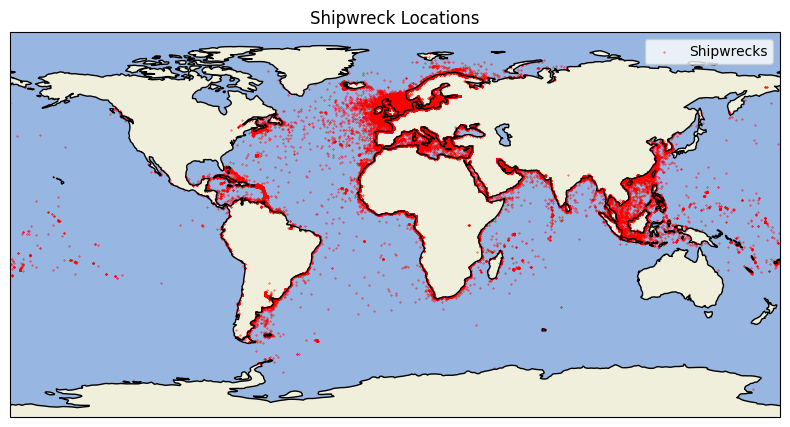

In [18]:
#Plotting the locations of the wrecks on a map.

# Function to convert DMM (e.g. "2 32.925 W") to decimal degrees
def dmm_to_dd(dmm_str):
    parts = dmm_str.split()
    degrees = float(parts[0])
    minutes = float(parts[1])
    direction = parts[2].upper()

    decimal = degrees + minutes / 60
    if direction in ['S', 'W']:
        decimal *= -1
    return decimal


points = gpd.read_file("Points.shp")

# Convert to decimal degrees
points['lat_dd'] = points['latitude'].apply(dmm_to_dd)
points['lon_dd'] = points['longitude'].apply(dmm_to_dd)

# Plotting with cartopy
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add basic features
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.set_global()

# Plot shipwreck points
ax.scatter(points['lon_dd'], points['lat_dd'], color='red', s=.1, label='Shipwrecks')

plt.title('Shipwreck Locations')
plt.legend()
plt.show()

In [22]:
# Replace None with 'Unknown' and clean up the flags
points['flag_clean'] = points['flag'].fillna('Unknown')

# Strip any leading/trailing whitespace from the flags
points['flag_clean'] = points['flag_clean'].str.strip()

# Replace entries starting with '?' (e.g., '?VIETNAMESE') with 'Unknown'
points['flag_clean'] = points['flag_clean'].replace(r'^\?', 'Unknown', regex=True)

# Fix any 'Unknown' entries that were incorrectly combined (e.g., 'UnknownMALAYSIAN')
points['flag_clean'] = points['flag_clean'].replace(r'^Unknown.*', 'Unknown', regex=True)

# Count and percentage
flag_counts = points['flag_clean'].value_counts()
flag_percentages = (flag_counts / len(points)) * 100

# Combine into summary DataFrame, including 'Unknown' as a category
flag_summary = pd.DataFrame({
    'Count': flag_counts,
    'Percentage': flag_percentages.round(2)
}).sort_values(by='Count', ascending=False)

# Show the summary
print(flag_summary)

            Count  Percentage
flag_clean                   
Unknown     79726       79.69
GB           8587        8.58
DE           1097        1.10
FR            981        0.98
NO            951        0.95
...           ...         ...
SINGAPORE       1        0.00
Tanzanian       1        0.00
Malaysia        1        0.00
ST              1        0.00
BEL             1        0.00

[175 rows x 2 columns]
